<div style="
    background:linear-gradient(135deg,#4F46E5,#6D5DFB);
    border-radius:14px;
    padding:24px 26px;
    margin:12px 0 24px 0;
">

<h1 style="
    color:white;
    margin:0;
    font-size:34px;
    font-weight:600;
">
Day 4 — t-SNE & Anomaly Detection
</h1>

<p style="
    color:#EEF2FF;
    margin:10px 0 0 0;
    font-size:17px;
">
Visualizing human activities and detecting unusual sensor records
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DDE2F1;
    border-left:5px solid #4F46E5;
    border-radius:11px;
    padding:17px 20px;
    margin:14px 0;
">

<h2 style="
    color:#4F46E5;
    margin:0 0 10px 0;
">
Introduction
</h2>

<p style="
    color:#374151;
    line-height:1.7;
    margin:0;
">
Yesterday, I used PCA to reduce the Human Activity Recognition dataset
while preserving most of its variance.

Today, I will use <b>t-SNE</b> to get a different visual view of the same
activities, then apply <b>Isolation Forest</b> to detect sensor records
that behave differently from the majority.
</p>

</div>

<div style="
    background:#EEF2FF;
    border-radius:11px;
    padding:17px 20px;
    margin:14px 0 22px 0;
">

<h2 style="
    color:#4338CA;
    margin:0 0 12px 0;
">
Today's Journey
</h2>

<div style="
    color:#374151;
    line-height:1.9;
    font-size:16px;
">

01 — Prepare the Human Activity Recognition data<br>
02 — Create a 2D t-SNE visualization<br>
03 — Compare t-SNE with PCA<br>
04 — Detect unusual records using Isolation Forest<br>
05 — Inspect flagged anomalies and explain possible reasons

</div>

</div>

<div style="background:#EEF2FF; border-left:5px solid #4F46E5; border-radius:10px; padding:16px 20px; margin:14px 0;">

<h2 style="color:#4338CA; margin-top:0;">Understanding t-SNE</h2>

<p style="color:#374151; line-height:1.7;">
High-dimensional data is difficult to explore visually because it contains more dimensions than we can directly plot.
Our activity dataset, for example, contains 561 sensor features, while a normal scatter plot can display only two or three dimensions.
</p>

<p style="color:#374151; line-height:1.7; margin-bottom:0;">
t-SNE reduces these features to two dimensions while trying to keep similar records close together.
This allows us to visually explore whether the human activities form clear local groups.
</p>

</div>

<div style="background:#F9FAFB; border:1px solid #E5E7EB; border-radius:10px; padding:18px 20px; margin:14px 0;">

<h3 style="color:#4F46E5; margin-top:0;">The Main Idea</h3>

<p style="color:#374151; line-height:1.7;">
Imagine that every record is a person standing in a crowded room.
Records with similar sensor readings are already standing near each other, while different records are farther apart.
</p>

<p style="color:#374151; line-height:1.7; margin-bottom:0;">
t-SNE moves this crowd onto a flat 2D map. It tries to keep nearby neighbors together, even though some of the wider distances may change during the move.
</p>

</div>

<div style="background:#FFFFFF; border:1px solid #E0E7FF; border-radius:10px; padding:18px 20px; margin:14px 0;">

<h3 style="color:#4338CA; margin-top:0;">What Does t-SNE Preserve?</h3>

<p style="color:#374151; line-height:1.7;">
t-SNE mainly preserves <b>local neighborhoods</b>.
Its priority is to keep similar points close together after reducing the dimensions.
</p>

<ul style="color:#374151; line-height:1.8; margin-bottom:0;">
<li>Nearby points may represent records with similar movement patterns.</li>
<li>Dense groups may reveal activities with similar sensor behavior.</li>
<li>Separated groups may indicate activities with noticeably different patterns.</li>
<li>The exact distance between separate groups should not be interpreted literally.</li>
</ul>

</div>

<div style="background:#EEF2FF; border-radius:10px; padding:18px 20px; margin:14px 0;">

<h3 style="color:#4338CA; margin-top:0;">How t-SNE Works — Simplified</h3>

<p style="color:#374151; line-height:1.7; margin-bottom:0;">
First, t-SNE identifies which records are neighbors in the original high-dimensional space.
It then creates a two-dimensional arrangement and repeatedly moves the points until nearby records remain close together as much as possible.
</p>

</div>

<div style="background-color:#FCFCFF; padding:22px; border:1px solid #EEEAFB; border-radius:16px;">

<h2 style="text-align:center; color:#5B55D6; margin-top:0;">
PCA vs. t-SNE
</h2>

<p style="text-align:center; color:#77758A; margin-bottom:20px;">
Same destination, different ways of understanding the data.
</p>

<table style="width:100%; border-collapse:separate; border-spacing:6px;">

<tr>
<th style="padding:12px; background-color:#F1F0F7; color:#656274; border-radius:9px;">
Point
</th>

<th style="padding:12px; background-color:#DDE2FF; color:#514AB5; border-radius:9px;">
PCA
</th>

<th style="padding:12px; background-color:#F1DEFA; color:#8553A3; border-radius:9px;">
t-SNE
</th>
</tr>

<tr>
<td style="padding:12px; background-color:#F5F4F9; color:#656274; border-radius:8px;"><b>Focus</b></td>
<td style="padding:12px; background-color:#EEF0FF; color:#4B4863; border-radius:8px;">Global variance</td>
<td style="padding:12px; background-color:#FAEEFF; color:#4B4863; border-radius:8px;">Local neighborhoods</td>
</tr>

<tr>
<td style="padding:12px; background-color:#F5F4F9; color:#656274; border-radius:8px;"><b>Main Use</b></td>
<td style="padding:12px; background-color:#EEF0FF; color:#4B4863; border-radius:8px;">Compression and visualization</td>
<td style="padding:12px; background-color:#FAEEFF; color:#4B4863; border-radius:8px;">Visual exploration</td>
</tr>

<tr>
<td style="padding:12px; background-color:#F5F4F9; color:#656274; border-radius:8px;"><b>Speed</b></td>
<td style="padding:12px; background-color:#EEF0FF; color:#4B4863; border-radius:8px;">Faster</td>
<td style="padding:12px; background-color:#FAEEFF; color:#4B4863; border-radius:8px;">Slower</td>
</tr>

<tr>
<td style="padding:12px; background-color:#F5F4F9; color:#656274; border-radius:8px;"><b>Axes</b></td>
<td style="padding:12px; background-color:#EEF0FF; color:#4B4863; border-radius:8px;">Show variance directions</td>
<td style="padding:12px; background-color:#FAEEFF; color:#4B4863; border-radius:8px;">Have no direct meaning</td>
</tr>

<tr>
<td style="padding:12px; background-color:#F5F4F9; color:#656274; border-radius:8px;"><b>Best For</b></td>
<td style="padding:12px; background-color:#EEF0FF; color:#4B4863; border-radius:8px;">Reducing features</td>
<td style="padding:12px; background-color:#FAEEFF; color:#4B4863; border-radius:8px;">Discovering visual groups</td>
</tr>

</table>

<div style="background-color:#F7F5FF; border-left:4px solid #A69DF5; border-radius:10px; padding:13px 16px; margin-top:18px; color:#57536B;">
<b style="color:#625BC7;">Little reminder:</b>
PCA protects the bigger picture, while t-SNE tries to keep close neighbors together.
</div>

</div>

### My Understanding

PCA helped me reduce the number of features while preserving most of the overall variance.  
t-SNE has a different goal: it helps me see which records behave like neighbors.

For this reason, I can use PCA for compression, but I will use t-SNE mainly to explore the activity patterns visually.

<div style="background:#FFF7ED; border-left:5px solid #F59E0B; border-radius:10px; padding:16px 20px; margin:14px 0;">

<b style="color:#B45309;">Important Note</b>

<p style="color:#374151; line-height:1.7; margin-bottom:0;">
t-SNE is a visualization tool, not a prediction model.
Its axes do not represent original features, and its output may change when parameters or the random seed change.
Therefore, the plot should be used to explore patterns, not as final proof that true clusters exist.
</p>

</div>

<div style="background:#FCFCFF; border-left:5px solid #8B7CF6; border-radius:12px; padding:17px 20px; margin:14px 0;">

<h2 style="color:#5B55D6; margin-top:0;">What Is Anomaly Detection?</h2>

<p style="color:#4B4863; line-height:1.7;">
Most sensor records follow common movement patterns. However, a small number of records may behave very differently from the majority.
</p>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
Anomaly detection helps us identify these unusual records. They may represent rare behavior, unexpected movement, sensor noise, or a possible data-quality problem.
</p>

</div>

<div style="background:#FFF8FC; border:1px solid #F2E4F1; border-radius:12px; padding:17px 20px; margin:14px 0;">

<h3 style="color:#A05A91; margin-top:0;">A Simple Example</h3>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
Imagine that most walking records show similar acceleration patterns. If one walking record contains extremely different sensor values, it may be flagged as an anomaly. This does not prove that the record is incorrect; it simply tells us that the record deserves closer inspection.
</p>

</div>

<div style="background:#F7F6FF; border-left:5px solid #A69DF5; border-radius:12px; padding:17px 20px; margin:14px 0;">

<h3 style="color:#625BC7; margin-top:0;">Why Is It Often Unsupervised?</h3>

<p style="color:#4B4863; line-height:1.7;">
In real datasets, unusual cases are rare and are not always labeled in advance. Therefore, the algorithm usually learns the general pattern of normal data without receiving a target column.
</p>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
After learning what common records look like, it flags the records that are easier to separate from the majority.
</p>

</div>

<div style="background:#FCFCFF; border:1px solid #E9E6FA; border-radius:12px; padding:18px 20px; margin:14px 0;">

<h2 style="color:#5B55D6; margin-top:0;">How Isolation Forest Finds Anomalies</h2>

<p style="color:#4B4863; line-height:1.7;">
Isolation Forest repeatedly makes random splits in the data. A record that is very different from the majority usually needs only a few splits to become isolated.
</p>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
Normal records are surrounded by many similar records, so separating one of them usually requires more splits.
</p>

</div>

<div style="background:#FFF9F1; border-left:5px solid #F2B76B; border-radius:12px; padding:17px 20px; margin:14px 0;">

<h3 style="color:#B7793B; margin-top:0;">The Contamination Parameter</h3>

<p style="color:#554E47; line-height:1.7;">
The contamination value represents the expected proportion of anomalies in the dataset.
For example, contamination = 0.05 tells the model to flag approximately 5% of the records as unusual.
</p>

<p style="color:#554E47; line-height:1.7; margin-bottom:0;">
This value does not prove that exactly 5% of the data is incorrect. It is an assumption that controls how strict the detection process will be.
</p>

</div>

<div style="background:#F5F3FF; border-radius:12px; padding:16px 20px; margin:14px 0;">

<b style="color:#625BC7;">Isolation Forest Output</b>

<p style="color:#4B4863; line-height:1.8; margin-bottom:0;">
<b>1</b> means the record was classified as normal.<br>
<b>-1</b> means the record was flagged as a possible anomaly.
</p>

</div>

<div style="background:#FFF8FC; border-left:5px solid #D99AC8; border-radius:12px; padding:16px 20px; margin:14px 0;">

<b style="color:#9A5688;">Important Reminder</b>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
An anomaly is not automatically an error. It may be a real but rare movement, a sensor issue, or a record that differs from the common activity pattern. The model flags suspicious records, but human interpretation is still needed.
</p>

</div>

<div style="background:#FCFCFF; border:1px solid #E9E6FA; border-radius:14px; padding:18px 21px; margin:14px 0;">

<h2 style="color:#5B55D6; margin-top:0;">
Anomaly Detection and Clustering
</h2>

<p style="color:#4B4863; line-height:1.8;">
Both 
<span style="color:#7C3AED; font-weight:600;">Clustering</span> 
and 
<span style="color:#C05A9D; font-weight:600;">Anomaly Detection</span> 
work without requiring predefined target labels, but they ask different questions.
</p>

<p style="color:#4B4863; line-height:1.8; margin-bottom:0;">
<span style="color:#7C3AED; font-weight:600;">Clustering</span> asks:
“Which records belong together?”  
While 
<span style="color:#C05A9D; font-weight:600;">Anomaly Detection</span> asks:
“Which records do not behave like the majority?”
</p>

</div>

<div style="background:#F8F7FF; border-left:5px solid #A69DF5; border-radius:13px; padding:18px 21px; margin:14px 0;">

<h3 style="color:#625BC7; margin-top:0;">
The Connection to DBSCAN
</h3>

<p style="color:#4B4863; line-height:1.8;">
In Day 2, 
<span style="color:#6D5BD0; font-weight:600;">DBSCAN</span> 
formed clusters from dense regions of the data.
Points that did not belong to a sufficiently dense region were labeled as 
<span style="color:#D05A8A; font-weight:600;">noise</span>.
</p>

<p style="color:#4B4863; line-height:1.8; margin-bottom:0;">
These noise points can be considered possible 
<span style="color:#D05A8A; font-weight:600;">anomalies</span>, 
which shows that clustering and anomaly detection can sometimes overlap.
</p>

</div>

<div style="background:#FFFDFE; border:1px solid #F0E7EF; border-radius:14px; padding:20px; margin:14px 0;">

<h3 style="text-align:center; color:#6B5DD3; margin-top:0;">
Same Data, Different Questions
</h3>

<table style="width:100%; border-collapse:separate; border-spacing:7px;">

<tr>
<th style="padding:12px; background-color:#F2F0F8; color:#656274; border-radius:9px;">
Method
</th>
<th style="padding:12px; background-color:#E8E5FF; color:#5B55B7; border-radius:9px;">
What Does It Look For?
</th>
<th style="padding:12px; background-color:#F9E8F2; color:#9A5688; border-radius:9px;">
Unusual Result
</th>
</tr>

<tr>
<td style="padding:12px; background-color:#F7F6FA; color:#4B4863; border-radius:8px;">
<b>DBSCAN</b>
</td>
<td style="padding:12px; background-color:#F3F1FF; color:#4B4863; border-radius:8px;">
Dense groups of nearby points
</td>
<td style="padding:12px; background-color:#FFF2F8; color:#4B4863; border-radius:8px;">
Noise point
</td>
</tr>

<tr>
<td style="padding:12px; background-color:#F7F6FA; color:#4B4863; border-radius:8px;">
<b>Isolation Forest</b>
</td>
<td style="padding:12px; background-color:#F3F1FF; color:#4B4863; border-radius:8px;">
Points that are easy to isolate
</td>
<td style="padding:12px; background-color:#FFF2F8; color:#4B4863; border-radius:8px;">
Anomaly
</td>
</tr>

</table>

<div style="background:#F8F6FF; border-left:4px solid #A69DF5; border-radius:10px; padding:13px 16px; margin-top:16px; color:#514C5F;">
<span style="color:#625BC7; font-weight:600;">The connection:</span>
Both methods can reveal unusual points, but they identify them using different ideas.
</div>

</div>

<div style="background:#FCFCFF; border-left:5px solid #B6A9F8; border-radius:13px; padding:18px 21px; margin:14px 0;">

<h3 style="color:#625BC7; margin-top:0;">
Why Isolation Forest for This Dataset?
</h3>

<p style="color:#4B4863; line-height:1.8;">
Our dataset contains 
<span style="color:#7C3AED; font-weight:600;">10,299 records</span> 
and 
<span style="color:#7C3AED; font-weight:600;">561 sensor features</span>.
Manually inspecting every record is not realistic.
</p>

<p style="color:#4B4863; line-height:1.8; margin-bottom:0;">
<span style="color:#C05A9D; font-weight:600;">Isolation Forest</span>
is suitable because it can work with high-dimensional data, does not require anomaly labels, and helps narrow thousands of records down to a smaller group that deserves investigation.
</p>

</div>

<div style="background:linear-gradient(90deg,#F0EEFF,#FCEFF8); border-radius:14px; padding:18px 21px; margin:18px 0;">

<h3 style="color:#5B55D6; margin-top:0;">
From Understanding to Experimenting
</h3>

<p style="color:#4B4863; line-height:1.8; margin-bottom:0;">
Now that the roles of 
<span style="color:#7C3AED; font-weight:600;">t-SNE</span> 
and 
<span style="color:#C05A9D; font-weight:600;">Isolation Forest</span> 
are clear, I can apply them to the human activity dataset: first to visualize its local structure, and then to investigate its unusual sensor records.
</p>

</div>

<div style="
    background:linear-gradient(135deg,#5146E5,#7968EE);
    border-radius:15px;
    padding:25px 28px;
    margin:24px 0;
    color:white;
">

<p style="
    margin:0 0 7px 0;
    color:#E9E7FF;
    font-size:14px;
    font-weight:600;
    letter-spacing:1px;
">
HANDS-ON LAB
</p>

<h1 style="
    margin:0;
    color:white;
    font-size:30px;
">
Visualizing Activities & Detecting Anomalies
</h1>

<p style="
    margin:12px 0 0 0;
    color:#F1F0FF;
    line-height:1.7;
">
Applying <span style="color:#FFD6EC; font-weight:600;">t-SNE</span> 
and <span style="color:#FFD6EC; font-weight:600;">Isolation Forest</span> 
to explore patterns and unusual records in smartphone sensor data.
</p>

</div>

<div style="
    background:#FCFCFF;
    border:1px solid #E9E6FA;
    border-radius:13px;
    padding:18px 21px;
    margin:14px 0;
">

<h3 style="color:#5B55D6; margin-top:0;">
Lab Roadmap
</h3>

<p style="color:#4B4863; line-height:2; margin-bottom:0;">
<span style="color:#7C3AED; font-weight:600;">01</span> — Prepare and scale the sensor features<br>
<span style="color:#7C3AED; font-weight:600;">02</span> — Visualize the activities using t-SNE<br>
<span style="color:#7C3AED; font-weight:600;">03</span> — Compare the t-SNE and PCA views<br>
<span style="color:#C05A9D; font-weight:600;">04</span> — Detect unusual records with Isolation Forest<br>
<span style="color:#C05A9D; font-weight:600;">05</span> — Inspect and interpret selected anomalies
</p>

</div>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

<div style="background:#FCFCFF; border-left:5px solid #8B7CF6; border-radius:13px; padding:18px 21px; margin:16px 0;">

<p style="color:#8B7CF6; font-size:13px; font-weight:600; letter-spacing:1px; margin:0;">
STEP 01
</p>

<h2 style="color:#5B55D6; margin:6px 0 10px 0;">
<b style="color:#625BC7;">1.1 — Load and Combine the Dataset</b>
</h2>

<p style="color:#4B4863; line-height:1.8; margin-bottom:0;">
Before asking 
<span style="color:#7C3AED; font-weight:600;">t-SNE</span>
to visualize the data or
<span style="color:#C05A9D; font-weight:600;">Isolation Forest</span>
to search for unusual records, I first need to understand what data they will receive.
</p>

</div>

<div style="background:#F7F6FF; border-radius:11px; padding:15px 18px; margin:12px 0;">

<b style="color:#625BC7;">Task</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
Load the training and testing files, combine them into one dataset, and create a quick summary of the available sensor records.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">Load the Dataset</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
First, I will load the training and testing files. Since I am using the data for visualization and anomaly detection, I will combine the two files so I can work with all the available records.
</p>

</div>

In [10]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (10299, 563)


<div style="background:#FFF9FC; border-left:4px solid #D99AC8; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#A05A91;">Observation</b>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
After combining the two files, the dataset contains 10,299 rows and 563 columns. This means I can use all the available sensor records in the analysis.
</p>

</div>

### Dataset Summary

I will create a small summary to check the dataset size, number of sensor features, and number of activities.

In [9]:
data_passport = pd.DataFrame({
    "Detail": [
        "Training records",
        "Testing records",
        "Total records",
        "Total columns",
        "Sensor features",
        "Activities"
    ],
    "Value": [
        train_df.shape[0],
        test_df.shape[0],
        df.shape[0],
        df.shape[1],
        df.shape[1] - 2,
        df["Activity"].nunique()
    ]
})

data_passport

,Detail,Value
0,Training records,7352
1,Testing records,2947
2,Total records,10299
3,Total columns,563
4,Sensor features,561
5,Activities,6


<div style="background:#FCFCFF; border:1px solid #E9E6FA; border-radius:13px; padding:17px 20px; margin:14px 0;">

<b style="color:#625BC7;">What This Tells Me</b>

<p style="color:#4B4863; line-height:1.8;">
The combined dataset contains
<span style="color:#7C3AED; font-weight:600;">10,299 sensor records</span>
describing
<span style="color:#C05A9D; font-weight:600;">6 human activities</span>.
Each record is represented by
<span style="color:#7C3AED; font-weight:600;">561 sensor features</span>.
</p>

<p style="color:#4B4863; line-height:1.8; margin-bottom:0;">
This large number of features explains why dimensionality reduction is necessary: the original data cannot be understood through a normal 2D plot.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">1.2 — Separate Features and Labels</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
I will separate the sensor features from 
<span style="color:#C05A9D; font-weight:600;">Activity</span>
and
<span style="color:#7C3AED; font-weight:600;">subject</span>.
The activity names will only be used later to color the points.
</p>

</div>

In [11]:
X = df.drop(columns=["subject", "Activity"])
y = df["Activity"]

print("Feature matrix shape:", X.shape)
print("Activity labels shape:", y.shape)
print("Number of activities:", y.nunique())

Feature matrix shape: (10299, 561)
Activity labels shape: (10299,)
Number of activities: 6


<div style="background:#FFF9FC; border-left:4px solid #D99AC8; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#A05A91;">Observation</b>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
The feature matrix contains
<span style="color:#7C3AED; font-weight:600;">10,299 records</span>
and
<span style="color:#7C3AED; font-weight:600;">561 sensor features</span>.
The
<span style="color:#C05A9D; font-weight:600;">6 activity labels</span>
were kept separately so they can be used to understand the t-SNE plot without affecting how t-SNE arranges the points.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #A69DF5; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">1.3 — Quick Data Check</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
Before scaling, I will check for missing values and make sure all the features are numeric.
</p>

</div>

In [12]:
print("Missing values:", X.isnull().sum().sum())
print("Non-numeric columns:", X.select_dtypes(exclude="number").shape[1])

Missing values: 0
Non-numeric columns: 0


<div style="background:#F3FAF7; border-left:4px solid #78BFA3; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#438B70;">Data Check Passed</b>

<p style="color:#40564E; line-height:1.7; margin-bottom:0;">
There are no missing values and all 561 features are numeric. The feature matrix is ready for scaling.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">1.4 — Scale the Features</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
The sensor features may have different ranges. I will use
<span style="color:#7C3AED; font-weight:600;">StandardScaler</span>
so that no feature affects the result only because its values are larger.
</p>

</div>

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)
print("Mean after scaling:", X_scaled.mean().round(2))
print("Standard deviation:", X_scaled.std().round(2))

Scaled data shape: (10299, 561)
Mean after scaling: 0.0
Standard deviation: 1.0


<div style="background:#FFF9FC; border-left:4px solid #D99AC8; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#A05A91;">Observation</b>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
The shape stayed
<span style="color:#7C3AED; font-weight:600;">10,299 × 561</span>,
so scaling did not remove any data. The new mean is close to
<span style="color:#C05A9D; font-weight:600;">0</span>
and the standard deviation is
<span style="color:#C05A9D; font-weight:600;">1</span>,
which confirms that the features are now on a similar scale.
</p>

</div>

<div style="background:linear-gradient(135deg,#5B55D6,#8B7CF6); border-radius:14px; padding:21px 24px; margin:20px 0;">

<p style="color:#EDEBFF; font-size:13px; font-weight:600; letter-spacing:1px; margin:0;">
STEP 02
</p>

<h2 style="color:white; margin:6px 0 8px 0;">
Visualize the Hidden Structure with t-SNE
</h2>

<p style="color:#F3F1FF; line-height:1.7; margin-bottom:0;">
Turning 561 sensor features into a 2D map to see which activity records naturally stay close together.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">2.1 — Select a Visualization Sample</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
t-SNE can be slow when it processes many records and features. I will select a random sample of
<span style="color:#C05A9D; font-weight:600;">3,000 records</span>
to make the visualization faster while still keeping examples from the different activities.
</p>

</div>

In [14]:
sample_indices = df.sample(
    n=3000,
    random_state=42
).index

X_sample = X_scaled[sample_indices]
y_sample = y.iloc[sample_indices].reset_index(drop=True)

print("Original records:", X_scaled.shape[0])
print("Sampled records:", X_sample.shape[0])
print("Features per record:", X_sample.shape[1])

Original records: 10299
Sampled records: 3000
Features per record: 561


<div style="background:#FFF9FC; border-left:4px solid #D99AC8; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#A05A91;">Sample Check</b>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
Before applying t-SNE, I will check that the random sample still contains records from all six activities.
</p>

</div>

In [15]:
sample_activity_counts = y_sample.value_counts()
sample_activity_counts

Activity
LAYING                583
SITTING               539
STANDING              533
WALKING               522
WALKING_DOWNSTAIRS    412
WALKING_UPSTAIRS      411
Name: count, dtype: int64

<div style="background:#F3FAF7; border-left:4px solid #78BFA3; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#438B70;">Observation</b>

<p style="color:#40564E; line-height:1.7;">
The sample contains records from all 
<span style="color:#5B55D6; font-weight:600;">six activities</span>.
<span style="color:#7C3AED; font-weight:600;">LAYING</span>
has the highest number of records with
<span style="color:#C05A9D; font-weight:600;">583</span>,
while
<span style="color:#7C3AED; font-weight:600;">WALKING_UPSTAIRS</span>
has the lowest with
<span style="color:#C05A9D; font-weight:600;">411</span>.
</p>

<p style="color:#40564E; line-height:1.7; margin-bottom:0;">
The difference is not very large, so no activity completely dominates the sample. This gives each activity enough points to appear clearly in the t-SNE visualization.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">2.2 — Apply t-SNE</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
Now I will use
<span style="color:#7C3AED; font-weight:600;">t-SNE</span>
to transform each sampled record from
<span style="color:#C05A9D; font-weight:600;">561 features</span>
into only
<span style="color:#C05A9D; font-weight:600;">2 dimensions</span>.
These two dimensions will be used to create the activity map.
</p>

</div>

In [16]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

The next cell may take some time because t-SNE repeatedly adjusts the positions of 3,000 points.

In [17]:
X_tsne = tsne.fit_transform(X_sample)

print("Shape before t-SNE:", X_sample.shape)
print("Shape after t-SNE:", X_tsne.shape)

Shape before t-SNE: (3000, 561)
Shape after t-SNE: (3000, 2)


<div style="background:#FFF9FC; border-left:4px solid #D99AC8; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#A05A91;">Observation</b>

<p style="color:#514C5F; line-height:1.7;">
t-SNE reduced the sample from
<span style="color:#7C3AED; font-weight:600;">561 features</span>
to
<span style="color:#C05A9D; font-weight:600;">2 dimensions</span>,
while keeping all
<span style="color:#7C3AED; font-weight:600;">3,000 records</span>.
</p>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
The two new values do not represent specific sensor measurements. They only describe where each record should appear on the 2D map based on its local similarity to other records.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">2.3 — Build the t-SNE Activity Map</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
I will plot the two t-SNE dimensions and give each
<span style="color:#C05A9D; font-weight:600;">activity</span>
a different color. This will help me see which activities form clear local groups and which ones overlap.
</p>

</div>

In [18]:
tsne_df = pd.DataFrame({
    "t-SNE 1": X_tsne[:, 0],
    "t-SNE 2": X_tsne[:, 1],
    "Activity": y_sample
})

tsne_df.head()

,t-SNE 1,t-SNE 2,Activity
0,32.487720,-9.465763,WALKING
1,-46.060059,10.289156,LAYING
2,-24.765829,-35.136654,STANDING
3,-22.690901,-39.312950,STANDING
4,40.314484,-9.202961,WALKING


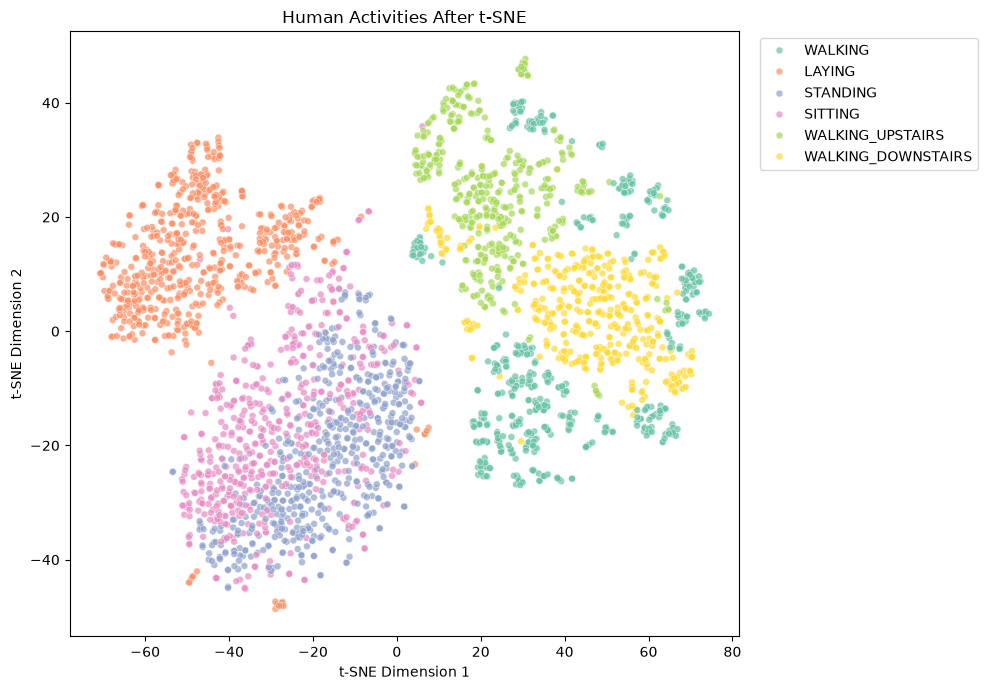

In [21]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=tsne_df,
    x="t-SNE 1",
    y="t-SNE 2",
    hue="Activity",
    palette="Set2",
    s=25,
    alpha=0.7
)

plt.title("Human Activities After t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">Observation</b>

<p style="color:#4B4863; line-height:1.7;">
The plot shows two main sides. The stationary activities appear mostly on the left, while the walking activities appear on the right.
</p>

<p style="color:#4B4863; line-height:1.7;">
<span style="color:#D97757; font-weight:600;">LAYING</span>
is more separated, while
<span style="color:#C05A9D; font-weight:600;">SITTING</span>
and
<span style="color:#6B78B8; font-weight:600;">STANDING</span>
overlap because both have similar low-movement sensor patterns.
</p>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
The three walking activities also have some overlap, but they still form clearer local areas. This shows that t-SNE captured useful differences between stationary and moving activities, although not every activity is completely separated.
</p>

</div>

<div style="background:linear-gradient(135deg,#5B55D6,#8B7CF6); border-radius:14px; padding:21px 24px; margin:20px 0;">

<p style="color:#EDEBFF; font-size:13px; font-weight:600; letter-spacing:1px; margin:0;">
STEP 03
</p>

<h2 style="color:white; margin:6px 0 8px 0;">
PCA vs. t-SNE
</h2>

<p style="color:#F3F1FF; line-height:1.7; margin-bottom:0;">
Looking at the same activity records in two different ways: the overall variance with
<span style="color:#FFD6EC; font-weight:600;">PCA</span>
and the local neighborhoods with
<span style="color:#FFD6EC; font-weight:600;">t-SNE</span>.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">3.1 — Create the PCA View</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
I will apply PCA to the same scaled sample and reduce it to two components. Using the same records makes the comparison with t-SNE fair.
</p>

</div>

In [22]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_sample)

print("PCA shape:", X_pca.shape)
print("Variance kept by PC1:", round(pca_2d.explained_variance_ratio_[0], 4))
print("Variance kept by PC2:", round(pca_2d.explained_variance_ratio_[1], 4))
print("Total variance kept:", round(pca_2d.explained_variance_ratio_.sum(), 4))

PCA shape: (3000, 2)
Variance kept by PC1: 0.5081
Variance kept by PC2: 0.0622
Total variance kept: 0.5703


<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">Observation</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
The first two PCA components kept
<span style="color:#C05A9D; font-weight:600;">57.03%</span>
of the total variance. Most of it came from
<span style="color:#7C3AED; font-weight:600;">PC1 (50.81%)</span>,
while PC2 added only
<span style="color:#7C3AED; font-weight:600;">6.22%</span>.
This means the 2D PCA view shows an important part of the data, but it does not represent all the information in the original 561 features.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">3.2 — Compare Both Views</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
I will place the PCA and t-SNE plots beside each other. Both plots use the same 3,000 records, so I can compare how each method shows the activity patterns.
</p>

</div>

In [23]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Activity": y_sample
})

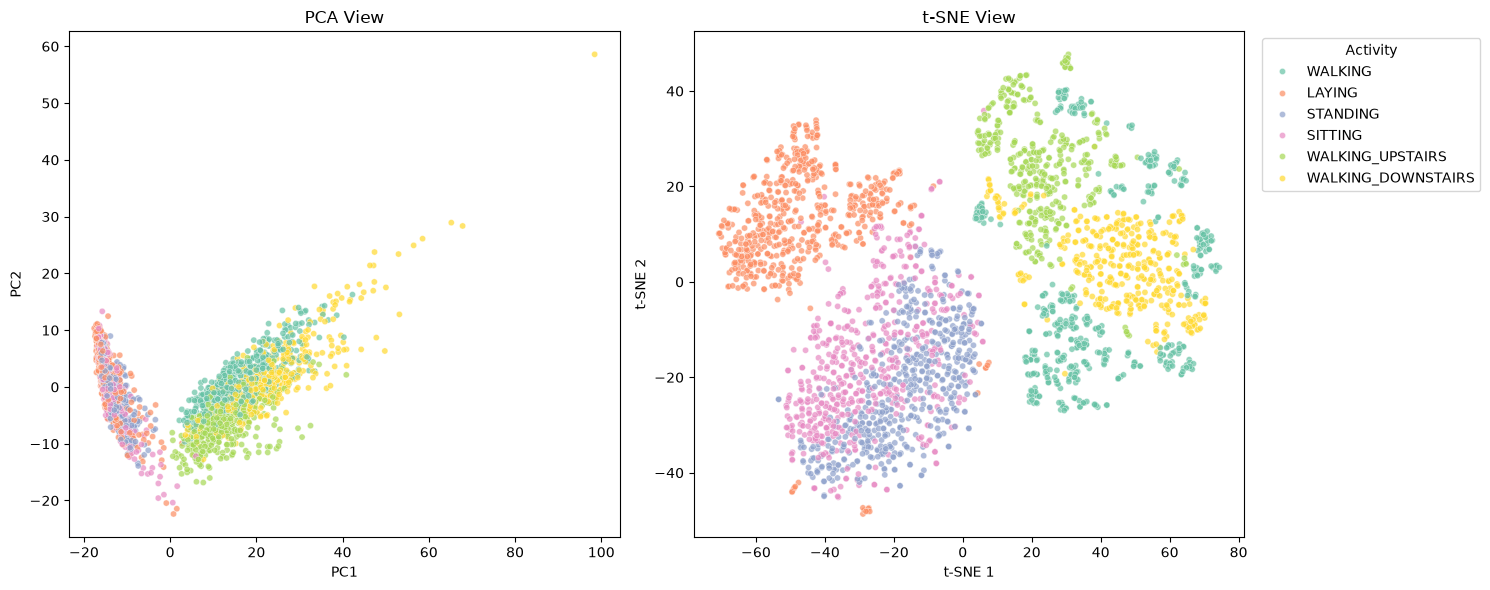

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Activity",
    palette="Set2",
    s=20,
    alpha=0.7,
    legend=False,
    ax=axes[0]
)

sns.scatterplot(
    data=tsne_df,
    x="t-SNE 1",
    y="t-SNE 2",
    hue="Activity",
    palette="Set2",
    s=20,
    alpha=0.7,
    ax=axes[1]
)

axes[0].set_title("PCA View")
axes[1].set_title("t-SNE View")

axes[1].legend(
    title="Activity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">Observation</b>

<p style="color:#4B4863; line-height:1.7;">
In the
<span style="color:#7C3AED; font-weight:600;">PCA view</span>,
the points follow one curved shape and several activity colors overlap. It gives a good view of the overall direction of the data, but the individual activities are not very clear.
</p>

<p style="color:#4B4863; line-height:1.7;">
In the
<span style="color:#C05A9D; font-weight:600;">t-SNE view</span>,
the local activity groups are easier to see. Laying is more separated, sitting and standing stay close together, and the walking activities appear mainly on the other side.
</p>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
This comparison shows that
<span style="color:#7C3AED; font-weight:600;">PCA is better for showing the overall variance</span>,
while
<span style="color:#C05A9D; font-weight:600;">t-SNE is better for visually exploring local groups</span>
in this dataset.
</p>

</div>

<div style="background:#FFF9F1; border-left:4px solid #E8B66C; border-radius:10px; padding:13px 17px; margin:12px 0; color:#514C5F;">

<b style="color:#B7793B;">A Question for the Next Step:</b>
Are the isolated points real unusual movements, or are they sensor records that differ strongly from the rest?

</div>

<div style="background:linear-gradient(135deg,#5B55D6,#8B7CF6); border-radius:14px; padding:21px 24px; margin:20px 0;">

<p style="color:#EDEBFF; font-size:13px; font-weight:600; letter-spacing:1px; margin:0;">
STEP 04
</p>

<h2 style="color:white; margin:6px 0 8px 0;">
Detect Unusual Sensor Records
</h2>

<p style="color:#F3F1FF; line-height:1.7; margin-bottom:0;">
Using
<span style="color:#FFD6EC; font-weight:600;">Isolation Forest</span>
to find records that behave differently from most of the dataset.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">4.1 — Run Isolation Forest</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
I will apply Isolation Forest to all
<span style="color:#7C3AED; font-weight:600;">10,299 records</span>.
I will start with
<span style="color:#C05A9D; font-weight:600;">contamination = 0.05</span>,
which tells the model to flag approximately 5% of the records as possible anomalies.
</p>

</div>

In [25]:
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_labels = iso_forest.fit_predict(X_scaled)
anomaly_scores = iso_forest.decision_function(X_scaled)

<div style="background:#F9F8FF; border-left:4px solid #A69DF5; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">4.2 — Save the Results</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
I will store the prediction and anomaly score beside each record so I can count and inspect the flagged cases.
</p>

</div>

In [26]:
anomaly_results = df[["subject", "Activity"]].copy()

anomaly_results["Prediction"] = anomaly_labels
anomaly_results["Anomaly Score"] = anomaly_scores

anomaly_results["Status"] = anomaly_results["Prediction"].map({
    1: "Normal",
    -1: "Anomaly"
})

anomaly_results.head()

,subject,Activity,Prediction,Anomaly Score,Status
0,1,STANDING,1,0.119924,Normal
1,1,STANDING,1,0.144326,Normal
2,1,STANDING,1,0.150370,Normal
3,1,STANDING,1,0.143007,Normal
4,1,STANDING,1,0.146577,Normal


<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">4.3 — Count the Detected Anomalies</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
Now I will count how many records were labeled as
<span style="color:#438B70; font-weight:600;">Normal</span>
and how many were flagged as
<span style="color:#C05A9D; font-weight:600;">Anomaly</span>.
I will also calculate their percentage from the complete dataset.
</p>

</div>

In [28]:
status_counts = anomaly_results["Status"].value_counts()

anomaly_count = status_counts["Anomaly"]
normal_count = status_counts["Normal"]
anomaly_percentage = (anomaly_count / len(anomaly_results)) * 100

print("Normal records:", normal_count)
print("Anomalies:", anomaly_count)
print("Anomaly percentage:", round(anomaly_percentage, 2), "%")

Normal records: 9784
Anomalies: 515
Anomaly percentage: 5.0 %


<div style="background:#FFF9FC; border-left:4px solid #D99AC8; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#A05A91;">Observation</b>

<p style="color:#514C5F; line-height:1.7;">
Isolation Forest classified
<span style="color:#438B70; font-weight:600;">9,784 records as normal</span>
and flagged
<span style="color:#C05A9D; font-weight:600;">515 records as possible anomalies</span>.
The flagged records represent
<span style="color:#7C3AED; font-weight:600;">5% of the dataset</span>.
</p>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
This percentage matches the selected
<span style="color:#C05A9D; font-weight:600;">contamination value of 0.05</span>.
However, it does not prove that all 515 records are errors; they are simply the records that appeared most unusual compared with the rest of the data.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">4.4 — Visualize the Detection Result</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
I will compare the number of
<span style="color:#438B70; font-weight:600;">normal records</span>
with the number of
<span style="color:#C05A9D; font-weight:600;">flagged anomalies</span>.
This makes the rarity of the unusual records easier to notice.
</p>

</div>

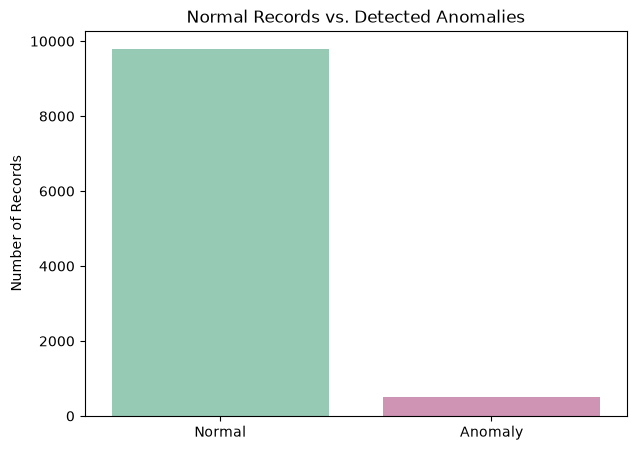

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=anomaly_results,
    x="Status",
    order=["Normal", "Anomaly"],
    palette=["#8DD3B7", "#D989B5"],
    hue="Status",
    legend=False
)

plt.title("Normal Records vs. Detected Anomalies")
plt.xlabel("")
plt.ylabel("Number of Records")
plt.show()

<div style="background:#FFF9FC; border-left:4px solid #D99AC8; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#A05A91;">Observation</b>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
The normal bar is much higher because
<span style="color:#438B70; font-weight:600;">95% of the records</span>
were considered normal, while only
<span style="color:#C05A9D; font-weight:600;">5%</span>
were flagged. This is expected because anomalies should represent a small part of the dataset.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #A69DF5; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">4.5 — Anomalies Across Activities</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
I will count the flagged records inside each activity. This can show whether unusual sensor patterns appear more often in a specific type of movement.
</p>

</div>

In [30]:
anomalies = anomaly_results[
    anomaly_results["Status"] == "Anomaly"
]

anomalies_by_activity = anomalies["Activity"].value_counts()
anomalies_by_activity

Activity
WALKING_DOWNSTAIRS    315
WALKING               120
WALKING_UPSTAIRS       55
LAYING                 20
SITTING                 5
Name: count, dtype: int64

<div style="background:#FFF9FC; border-left:4px solid #D99AC8; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#A05A91;">Observation</b>

<p style="color:#514C5F; line-height:1.7;">
<span style="color:#C05A9D; font-weight:600;">WALKING_DOWNSTAIRS</span>
has the highest number of flagged records with
<span style="color:#7C3AED; font-weight:600;">315 anomalies</span>,
followed by WALKING with 120 and WALKING_UPSTAIRS with 55.
</p>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
Only a few anomalies appeared in LAYING and SITTING, while
<span style="color:#438B70; font-weight:600;">STANDING did not appear in the anomaly list</span>.
However, I still need to compare percentages before deciding which activity has the highest anomaly rate.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">4.6 — Calculate the Anomaly Rate</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
The anomaly count may be affected by the original size of each activity. I will calculate the percentage of flagged records inside every activity to make the comparison fair.
</p>

</div>

In [31]:
activity_summary = pd.crosstab(
    anomaly_results["Activity"],
    anomaly_results["Status"]
)

activity_summary["Anomaly Rate (%)"] = (
    activity_summary["Anomaly"] /
    activity_summary.sum(axis=1)
) * 100

activity_summary.round(2)

Status,Anomaly,Normal,Anomaly Rate (%)
Activity,,,
LAYING,20,1924,1.03
SITTING,5,1772,0.28
STANDING,0,1906,0.00
WALKING,120,1602,6.97
WALKING_DOWNSTAIRS,315,1091,22.40
WALKING_UPSTAIRS,55,1489,3.56


<div style="background:#FFF9FC; border-left:4px solid #D99AC8; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#A05A91;">Observation</b>

<p style="color:#514C5F; line-height:1.7;">
<span style="color:#C05A9D; font-weight:600;">WALKING_DOWNSTAIRS</span>
has the highest anomaly rate at
<span style="color:#7C3AED; font-weight:600;">22.40%</span>.
It is much higher than WALKING at 6.97% and WALKING_UPSTAIRS at 3.56%.
</p>

<p style="color:#514C5F; line-height:1.7;">
The stationary activities have much lower rates:
LAYING has 1.03%, SITTING has 0.28%, and STANDING has 0%.
</p>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
This suggests that going downstairs produces more varied or unusual sensor patterns. However, the flagged records are not necessarily errors; the movement itself may naturally be less regular than sitting or standing.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">4.7 — Compare Anomaly Rates</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
I will plot the anomaly percentage for each activity. Using percentages makes the comparison fair even when the activities contain different numbers of records.
</p>

</div>

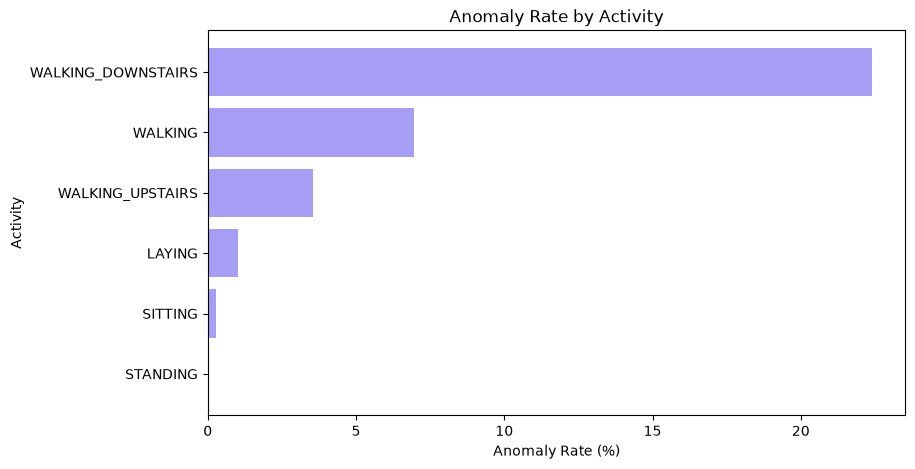

In [32]:
anomaly_rates = activity_summary["Anomaly Rate (%)"].sort_values()

plt.figure(figsize=(9, 5))
plt.barh(
    anomaly_rates.index,
    anomaly_rates.values,
    color="#A69DF5"
)

plt.title("Anomaly Rate by Activity")
plt.xlabel("Anomaly Rate (%)")
plt.ylabel("Activity")
plt.show()

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">Observation</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
The chart makes the difference clear:
<span style="color:#C05A9D; font-weight:600;">WALKING_DOWNSTAIRS</span>
stands out with a 22.40% anomaly rate, while the stationary activities remain close to zero. The model mainly found unusual patterns in activities that involve more movement.
</p>

</div>

<div style="background:linear-gradient(135deg,#5B55D6,#8B7CF6); border-radius:14px; padding:21px 24px; margin:20px 0;">

<p style="color:#EDEBFF; font-size:13px; font-weight:600; letter-spacing:1px; margin:0;">
STEP 05
</p>

<h2 style="color:white; margin:6px 0 8px 0;">
Inspect the Most Unusual Records
</h2>

<p style="color:#F3F1FF; line-height:1.7; margin-bottom:0;">
Looking beyond the anomaly label to understand what made selected sensor records stand out.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">5.1 — Select Two Flagged Records</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
I will inspect the two records with the
<span style="color:#C05A9D; font-weight:600;">lowest anomaly scores</span>.
A lower score means that Isolation Forest considered the record easier to isolate and more unusual.
</p>

</div>

In [33]:
most_unusual = anomaly_results.nsmallest(
    2,
    "Anomaly Score"
)

most_unusual

,subject,Activity,Prediction,Anomaly Score,Status
3935,19,WALKING_DOWNSTAIRS,-1,-0.209386,Anomaly
3936,19,WALKING_DOWNSTAIRS,-1,-0.196696,Anomaly


<div style="background:#FFF9FC; border-left:4px solid #D99AC8; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#A05A91;">Observation</b>

<p style="color:#514C5F; line-height:1.7;">
The two lowest-scoring records belong to
<span style="color:#7C3AED; font-weight:600;">subject 19</span>
and both represent
<span style="color:#C05A9D; font-weight:600;">WALKING_DOWNSTAIRS</span>.
This agrees with the previous result, where this activity had the highest anomaly rate.
</p>

<p style="color:#514C5F; line-height:1.7;">
Record
<span style="color:#7C3AED; font-weight:600;">3935</span>
has the lower score of
<span style="color:#C05A9D; font-weight:600;">−0.2094</span>,
so it was considered slightly more unusual than record 3936, which scored −0.1967.
</p>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
The records are consecutive, which may mean they came from the same short period of unusual movement. However, I need to inspect their feature values before suggesting what made them different.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">5.2 — Find the Strongest Deviations</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
For each selected record, I will find the five features with the largest absolute scaled values. These features give me clues about which sensor measurements were farthest from their usual range.
</p>

</div>

In [34]:
record_ids = most_unusual.index.tolist()

for record_id in record_ids:
    feature_deviation = pd.Series(
        abs(X_scaled[record_id]),
        index=X.columns
    ).nlargest(5)

    print("Record:", record_id)
    print("Activity:", df.loc[record_id, "Activity"])
    display(feature_deviation.to_frame("Absolute Scaled Value"))

Record: 3935
Activity: WALKING_DOWNSTAIRS


,Absolute Scaled Value
"fBodyGyro-bandsEnergy()-33,40.1",30.975077
"fBodyGyro-bandsEnergy()-33,40.2",29.862388
"fBodyGyro-bandsEnergy()-33,48.2",28.938909
"fBodyGyro-bandsEnergy()-33,48.1",28.710963
"fBodyGyro-bandsEnergy()-25,48.2",27.541654


Record: 3936
Activity: WALKING_DOWNSTAIRS


,Absolute Scaled Value
"fBodyGyro-bandsEnergy()-33,40.1",33.871778
"fBodyGyro-bandsEnergy()-33,48.1",30.498917
"fBodyGyro-bandsEnergy()-41,48.1",19.568894
"fBodyGyro-bandsEnergy()-25,48.1",19.024404
"fBodyGyro-bandsEnergy()-25,32.1",14.787573


<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:15px 18px; margin:12px 0;">

<b style="color:#625BC7;">Observation</b>

<p style="color:#4B4863; line-height:1.7;">
<b style="color:#7C3AED;">Record 3935:</b>
The five strongest deviations are all related to
<span style="color:#C05A9D; font-weight:600;">gyroscope band energy</span>.
The largest value is
<span style="color:#7C3AED; font-weight:600;">33.87</span>,
which shows that its rotational sensor behavior is far from the usual range.
</p>

<hr style="border:none; border-top:1px solid #E5E1F5; margin:12px 0;">

<p style="color:#4B4863; line-height:1.7;">
<b style="color:#7C3AED;">Record 3936:</b>
This record shows a similar pattern, with all five deviations also coming from gyroscope-energy features. Its highest value is
<span style="color:#C05A9D; font-weight:600;">30.98</span>.
</p>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
Both records belong to the same subject, activity, and consecutive rows. This suggests that they may represent the same short period of unusually strong or irregular movement while walking downstairs.
</p>

</div>

<div style="background:#F9F8FF; border-left:4px solid #8B7CF6; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#625BC7;">5.3 — Interpret the Two Records</b>

<p style="color:#4B4863; line-height:1.7; margin-bottom:0;">
I will compare the strongest deviations in the two records and suggest why Isolation Forest may have considered them unusual.
</p>

</div>

<div style="background:#FFF9F1; border-left:4px solid #E8B66C; border-radius:10px; padding:14px 17px; margin:12px 0;">

<b style="color:#B7793B;">My Hypothesis</b>

<p style="color:#514C5F; line-height:1.7; margin-bottom:0;">
The two records may represent a short period when the phone or the participant's body rotated more strongly than usual while walking downstairs. They may also contain temporary sensor noise. Without true anomaly labels, I cannot confirm the exact cause, so I treat them as unusual records rather than definite errors.
</p>

</div>

<div style="background:#FCFCFF; border:1px solid #E9E6FA; border-radius:14px; padding:20px; margin:22px 0;">

<h2 style="color:#5B55D6; text-align:center; margin-top:0;">
Final Conclusion
</h2>

<p style="color:#77758A; text-align:center;">
A quick look at what each method revealed.
</p>

<table style="width:100%; border-collapse:separate; border-spacing:6px;">

<tr>
<th style="padding:12px; background:#E8E5FF; color:#5B55B7; border-radius:9px;">
Part
</th>
<th style="padding:12px; background:#F5E7F1; color:#985982; border-radius:9px;">
Main Result
</th>
<th style="padding:12px; background:#E8F5F0; color:#438B70; border-radius:9px;">
What It Means
</th>
</tr>

<tr>
<td style="padding:12px; background:#F3F1FF; color:#625BC7; border-radius:8px;">
<b>t-SNE</b>
</td>
<td style="padding:12px; background:#FFF3F8; color:#514C5F; border-radius:8px;">
Stationary and walking activities appeared on different sides.
</td>
<td style="padding:12px; background:#F1FAF6; color:#514C5F; border-radius:8px;">
t-SNE revealed useful local activity groups.
</td>
</tr>

<tr>
<td style="padding:12px; background:#F3F1FF; color:#625BC7; border-radius:8px;">
<b>PCA</b>
</td>
<td style="padding:12px; background:#FFF3F8; color:#514C5F; border-radius:8px;">
The first two components kept <b>57.03%</b> of the variance.
</td>
<td style="padding:12px; background:#F1FAF6; color:#514C5F; border-radius:8px;">
PCA showed the overall structure, but the activities overlapped more.
</td>
</tr>

<tr>
<td style="padding:12px; background:#F3F1FF; color:#625BC7; border-radius:8px;">
<b>Isolation Forest</b>
</td>
<td style="padding:12px; background:#FFF3F8; color:#514C5F; border-radius:8px;">
It flagged <b>515 records</b>, equal to <b>5%</b> of the dataset.
</td>
<td style="padding:12px; background:#F1FAF6; color:#514C5F; border-radius:8px;">
These are possible anomalies that need inspection, not confirmed errors.
</td>
</tr>

<tr>
<td style="padding:12px; background:#F3F1FF; color:#625BC7; border-radius:8px;">
<b>Highest Rate</b>
</td>
<td style="padding:12px; background:#FFF3F8; color:#514C5F; border-radius:8px;">
WALKING_DOWNSTAIRS reached <b>22.40%</b>.
</td>
<td style="padding:12px; background:#F1FAF6; color:#514C5F; border-radius:8px;">
This activity produced more varied sensor patterns.
</td>
</tr>

<tr>
<td style="padding:12px; background:#F3F1FF; color:#625BC7; border-radius:8px;">
<b>Record Check</b>
</td>
<td style="padding:12px; background:#FFF3F8; color:#514C5F; border-radius:8px;">
Records 3935 and 3936 had large gyroscope-energy deviations.
</td>
<td style="padding:12px; background:#F1FAF6; color:#514C5F; border-radius:8px;">
They may contain unusual movement or temporary sensor noise.
</td>
</tr>

</table>

<div style="background:#F7F5FF; border-left:4px solid #A69DF5; border-radius:9px; padding:13px 16px; margin-top:16px; color:#514C5F;">
<b style="color:#625BC7;">Final Takeaway:</b>
PCA showed the overall variance, t-SNE made the local groups clearer, and Isolation Forest highlighted records that deserve further investigation.
</div>

</div>